In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib as mt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pywt
from math import floor
import joblib

This notebook will walk through the process for a semi-supervised learning pipeline to categorize triggered pulses in phase-III BeEST data. This process is based off of work done by L&#233;on et al. for the LEGEND experiment [1, DOI 10.1088/2632-2153/adbb37]. Most processes are done in seperate python scripts. Some data exploration and explanations will be made in this notebook. 

The pipeline consists of four primary steps: data selection, preprocessing, unsupervised clustering, and supervised classification. 

All code related to this project can be found at this [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST). 

# Overview

This model was developed using multiple individual python scripts which do the following: 

 * Get pulses from raw data: `pulseGrabber.py`
 * Select $N$ pulses to train an ML model: `getNPulses.py`
 * Run a parameter seach to find the optimal AP model: `apParamSweep.py`
 * Manually sort clusters from the best AP model: ***TO DO***
 * Run a parameter seach to find the optimal SVM model: `svmParamSweep.py` ***(see [1] for more info when writing this)***


## LEGEND Overview

Below is an overview of the LEGEND semisupervised model that this work is based on [1].

The technique is semi-supervised, with a clustering algorithm (affinity propagation, AP) to cluster waveforms based on shape, and an SVM to classify them into categories. 

LEGEND uses HPGe semi-conductor detectors in a liquid argon bath. They look at $0\nu\beta\beta$ in $\text{Ge}^{76}$, looking at energies $\approx 2000 \text{ keV} \rightarrow \mathcal{O}(\text{MeV})$ 

Data is digitized by a FlashCam ADC (62.5 MHz$\rightarrow 16$ ns per sample), decoded into an HDF5 file, and processed with LEGEND's custom `pygama` library. They used 8192 samples per pulse.

The general pipeline for the ML-powered data cleaning model is as follows:

* Extract pulse shape info from waveforms
* Group similar waveforms w/ unsupervised model and relabel w/ user input
* Extend clustering power to larger datasets using SVM

This lead to a maximum sacrifice of $0.024^{+0.004}_{-0.003}\%$ of physics events for LEGEND. 

## BeEST Extension

We use Ta-STJs as sensors and look at $^7$Be decay implanted in the STJs, with the ROI on the scale of eV: [20,120 eV] (typically plot up to 350 eV). Energies outside this ROI are also possible. The STJs enables an energy resolution of $\approx 1 \textendash 2$ eV FWHM. We have a calibration laser (100 Hz) to create single photon events at intervals of $3.49865(15)$ eV. 

Phase-III utilizes a DAQ to sample voltage continuously. Based on two 8-channel NI PXIe-6356 cards (16-bit voltage samples, at 1.25 MHz$\rightarrow 0.8$ $\mu$s per sample) from 8 STJ preamplifiers. Wrote to disc in 10-minute increments of 12 GB. Timing between cards is synchronized to 0.2 $\mu$s. Cards 1 and 2 are  refered to as `sig_a` and `sig_b`, respectively. 

Phase-III Ta-STJs signals have amplitudes $\approx 150 \text{ nA/keV}$, rise times $\tau_{\text{rise}}\approx 1$ $\mu$s, and decay times $\tau_{\text{decay}}\approx 100$ $\mu$s (from charge recombination times in junction electrodes). Decay times differed slightly for different pixels and ADR cycles. I used 2048 samples per pulse. 

# Data Selection

I looked at two datasets: all channels from day 33 and channel 3 from day 16. All raw waveform data was from `TDMS` files found in `/beest_data/20221019-20221227_FirstCollectionRun/` on `CRONOS`. Information on the triggered data was from `HDF5` files found in `/beest_data/finalProcessingBlinded-20250519/` on `CRONOS`. 

All analysis done in this notebook is from day 16 channel 3.

I modified a python script from Dr. Drew Marino to select each waveform using the triggered data from the `HDF5` files and save the waveform from the `TDMS` files. Metadata (see below) about the pulses was saved from the `HDF5` file. 

The pulse selection code can be found at the [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST) in the file `pulseGrabber.py`. This saves all triggered pulses and metadata from each 10-minute time chunk to one numpy array. For each channel, each 10-minute time chunk has $\approx$ 1&ndash;1.3 GB of pulses. This results in $\approx100$ GB for one channel.

The unsupervised affinity propagation model (AP) scales with $\mathcal{O}(n^2)$ for time and memory, so we will limit to $10000$ samples. The $N$ pulses selection code can be found at the [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST) in the file `getNPulses.py`.

Below is an example of a pulse from day 16, channel 3 loaded from the selected pulses. 

Each pulse has a:

 * Waveform (128 samples pre-trigger + 1920 post-trigger = 2048 samples)
 * Laser (boolean for laser on or off)
 * Multiplicity
 * Energy

Each `.npy` file has all triggered pulses ($\approx 80 000$ pulses) in the 10-minute time chunk from the DAQ. I have saved one pulse from the first time chunk. Lets look at it.

In [17]:
PRE_PULSE_LEN = int(2**7)
PULSE_LEN = int(2**11 - PRE_PULSE_LEN)

In [8]:
one_pulse = np.load('/home/cmhinkle/26_ml_data_clean/feb_clustering/semi_supervised_pulses_BeEST/data/one_pulses_day16_chan3.npy')

In [10]:
waveform = one_pulse['waveform']
energy = one_pulse['energy']
laser = one_pulse['ig_laser']
mult = one_pulse['multiplicity']

In [12]:
print(f'Energy of this pulse is {energy:.2f} eV')
print(f'Laser was on for this pulse: {laser}')
print(f'Multplicity of this pulse is {mult}')

Energy of this pulse is 107.01 eV
Laser was on for this pulse: True
Multplicity of this pulse is 16


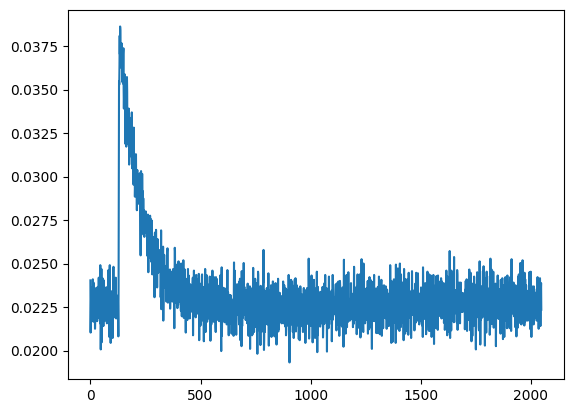

In [11]:
plt.plot(waveform)
plt.show()
plt.close()

# Preprocessing

Each pulse was normalized and downsampled before being fed into the clustering model. Downsampling was performed using a discrete wavelet transform (DWT). DWT decomposes a waveform into "mutually orthogonal down-sampled sets of time-series coefficients by convolving the input signal with a given type of wavelet" and can be performed multiple times on the same input signal [1]. The DWT outputs approximation coefficents (AC) and detail coefficents (DC), which describe the low and high frequency components of the input signal. The DWT de-noises and reduces the dimension of an input waveform. 

DWT "decomposes the waveform into mutually orthogonal down-sampled sets of time-series coefficients by convolving the input signal with a given type of wavelet" [1]. It can be done multiple, $l$, times on the same signal, with a multilevel decomposition with a factor of $2^l$.

The DWT outputs approimate coefficents (aC, low freq $\rightarrow$ low pass filter) and detail coefficents (dC, high freq$\rightarrow$ high pass filter) components of the input signal. They take AC as a lower-dimensional representation of input waveform. 

[1] used the Haar wavelet for DWT to preserve the rising edge shape and the decay time.

***need to explain why $l$ was chosen and the wavelet. also talk about timing***

In [18]:
# Apply DWT
wavelet='haar'
coeffs = pywt.wavedec(waveform, wavelet, level=3)
cA3, cD3, cD2, cD1 = coeffs # cA3 is smoothed with 1/8 length of normal time

prepulse_len_dwt = PRE_PULSE_LEN // 8

In [22]:
# Apply offset
offset = np.median(cA3[:(prepulse_len_dwt//2)])
baseline_pulse = np.subtract(cA3, offset)

In [26]:
# Find max or min
max_min = np.maximum(
    np.max(baseline_pulse),
    np.abs(np.min(baseline_pulse))
)

In [31]:
# Normalize to [-1,1]
norm_pulse = np.divide(baseline_pulse, max_min)

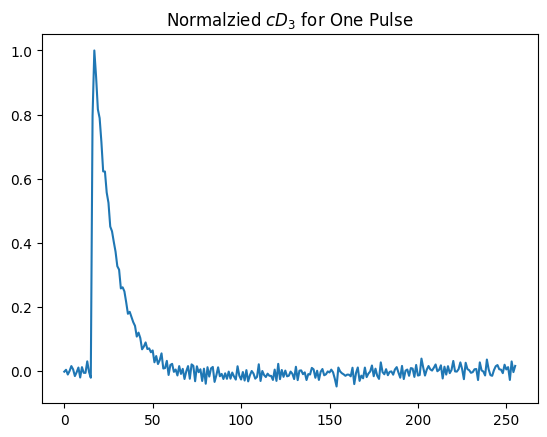

In [32]:
# Normalized pulse
plt.plot(norm_pulse)
plt.title(r'Normalzied $cD_3$ for One Pulse')
plt.show()
plt.close()

Now the data is ready to be fed into the AP model. All pulses will be normalized to [-1,1] and downsampled from 2048 to 256 samples. This makes the each sample represents 6.4 $\mu$s.  

Below is a sample of 64 processed pulses.

![processed_pulses](../outputs/figs/norm_pulses_day16_chan3.svg "Processed Pulses")

I looked at two datasets: all channels from day 33 and channel 3 from day 16. All raw waveform data was from `TDMS` files found in `/beest_data/20221019-20221227_FirstCollectionRun/` on `CRONOS`. Information on the triggered data was from `HDF5` files found in `/beest_data/finalProcessingBlinded-20250519/` on `CRONOS`. 

I modified a python script from Dr. Drew Marino to select each waveform using the triggered data from the `HDF5` files and save the waveform from the `TDMS` files. Metadata (see below) about the pulses was saved from the `HDF5` file. 

The pulse selection code can be found at the [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST) in the file `pulseGrabber.py`. This saves all triggered pulses and metadata from each 10-minute time chunk to one numpy array. For each channel, each 10-minute time chunk has $\approx$ 1&ndash;1.3 GB of pulses. This results in $\approx100$ GB for one channel.

## Select pulses

The unsupervised method scales with $\mathcal{O}(n^2)$ for time and memory, so we will limit to 5000 samples. Below is an example of a pulse from day 16, channel 3 loaded from the selected pulses. 

Each pulses has a:

 * Waveform (128 samples pre-trigger + 1920 post-trigger = 2048 samples)
 * Laser (boolean for laser on or off)
 * Multiplicity
 * Energy
 * Laser offset

In [3]:
prepulse_len = int(2**7)
pulse_len = int(2**11 - prepulse_len)

In [4]:
pulses_0 = np.load('/data_fast/chinkle/26_ml/allPulses/out_pulses_16_chans_3/20221106-223352.840919_A_000_03.npy')

In [5]:
print(f'There are {len(pulses_0)} pulses in time chunk 0')

There are 83679 pulses in time chunk 0


In [7]:
np.save('/home/cmhinkle/26_ml_data_clean/feb_clustering/semi_supervised_pulses_BeEST/data/one_pulses_day16_chan3.npy', pulses_0[0])

Each `.npy` file has all triggered pulses in the 10-minute time chunk from the DAQ. Lets look at the first pulse.

In [9]:
pulse_01 = pulses_0[0]

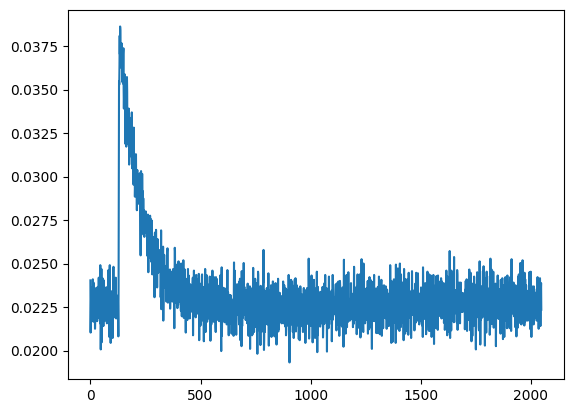

In [10]:
plt.plot(pulse_01['waveform'])
plt.show()
plt.close()

In [12]:
energy = pulse_01['energy']
laser = pulse_01['ig_laser']
mult = pulse_01['multiplicity']

In [13]:
print(f'Energy of pulse 0 is {energy:.2f} eV')
print(f'Laser was on for pulse 0: {laser}')
print(f'Multplicity of pulse 0 is {mult}')

Energy of pulse 0 is 107.01 eV
Laser was on for pulse 0: True
Multplicity of pulse 0 is 16


I used a python script to randomly select $N$ pulses from a day of data. In this notebook I will look at a selection of 10 000 pulses from day16, channel 3.

In [15]:
pulses = np.load('/data_fast/chinkle/26_ml/selectedPulses/day16_chan03_10000_20260803.npy')

In [16]:
len(pulses)

10000

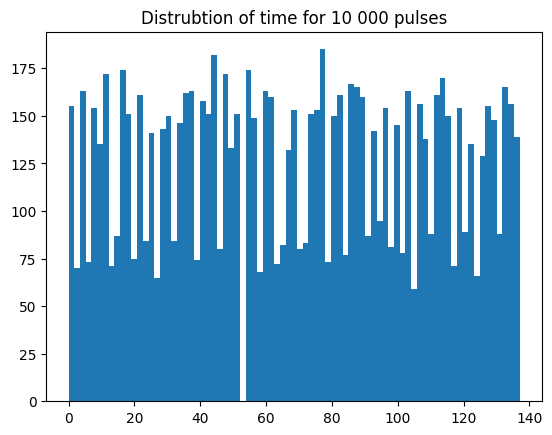

In [19]:
#plt.hist(pulses['chunk'], bins = floor(np.sqrt(len(pulses['chunk']))))
plt.hist(pulses['chunk'], bins = int(2 * len(pulses['chunk'])**(2/5)))
plt.title('Distrubtion of time for 10 000 pulses')
plt.show()
plt.close()

Each pulse was normalized and downsampled before being fed into the clustering model. Downsampling was performed using a discrete wavelet transform (DWT). DWT decomposes a waveform into "mutually orthogonal down-sampled sets of time-series coefficients by convolving the input signal with a given type of wavelet" and can be performed multiple times on the same input signal [1]. The DWT outputs approximation coefficents (AC) and detail coefficents (DC), which describe the low and high frequency components of the input signal. The DWT de-noises and reduces the dimension of an input waveform. 

DWT "decomposes the waveform into mutually orthogonal down-sampled sets of time-series coefficients by convolving the input signal with a given type of wavelet" [1]. It can be done multiple, $l$, times on the same signal, with a multilevel decomposition with a factor of $2^l$.

The DWT outputs approimate coefficents (aC, low freq $\rightarrow$ low pass filter) and detail coefficents (dC, high freq$\rightarrow$ high pass filter) components of the input signal. They take AC as a lower-dimensional representation of input waveform. 

[1] used the Haar wavelet for DWT to preserve the rising edge shape and the decay time.

In [22]:
# Apply DWT to waveforms 
    # NOTE level should be good, look into different wavelets
wavelet='haar'
level=3
coeffs = pywt.wavedec(pulses['waveform'], wavelet, level=level)
cA3, cD3, cD2, cD1 = coeffs # cA3 is a smoothed with 1/8 length of normal

time8 = range(int(floor(prepulse_len + pulse_len)/8))
prepulse_len_dwt = floor(prepulse_len/8)
pulse_len_dwt = floor(pulse_len/8)

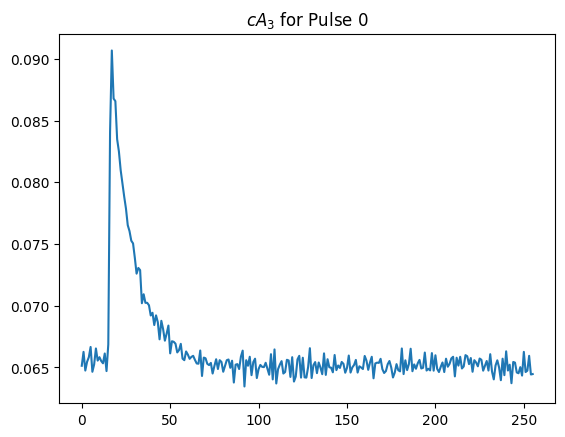

In [23]:
plt.plot(cA3[0])
plt.title(r'$cA_3$ for Pulse 0')
plt.show()
plt.close()

In [24]:
# Apply offset
offsets = np.median(cA3[:,:floor(prepulse_len_dwt/2)], axis=1)
baselinePulses = np.subtract(cA3, offsets[:, None])

In [25]:
# Find max or min
maxMin = np.maximum(
    np.max(baselinePulses, axis=1),
    np.abs(np.min(baselinePulses, axis=1))
)[:, None]


In [26]:
# Normalize to [-1,1]
normPulses = np.divide(baselinePulses, maxMin)

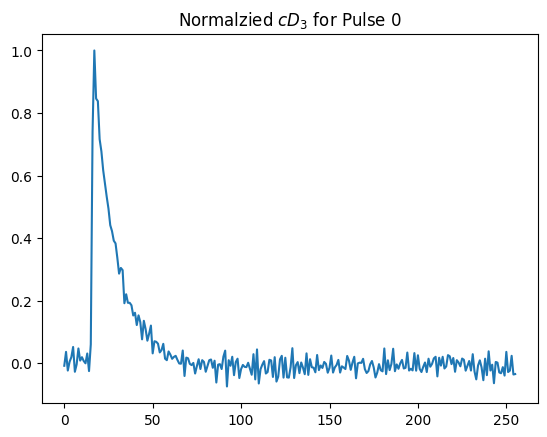

In [27]:
plt.plot(normPulses[0])
plt.title(r'Normalzied $cD_3$ for Pulse 0')
plt.show()
plt.close()

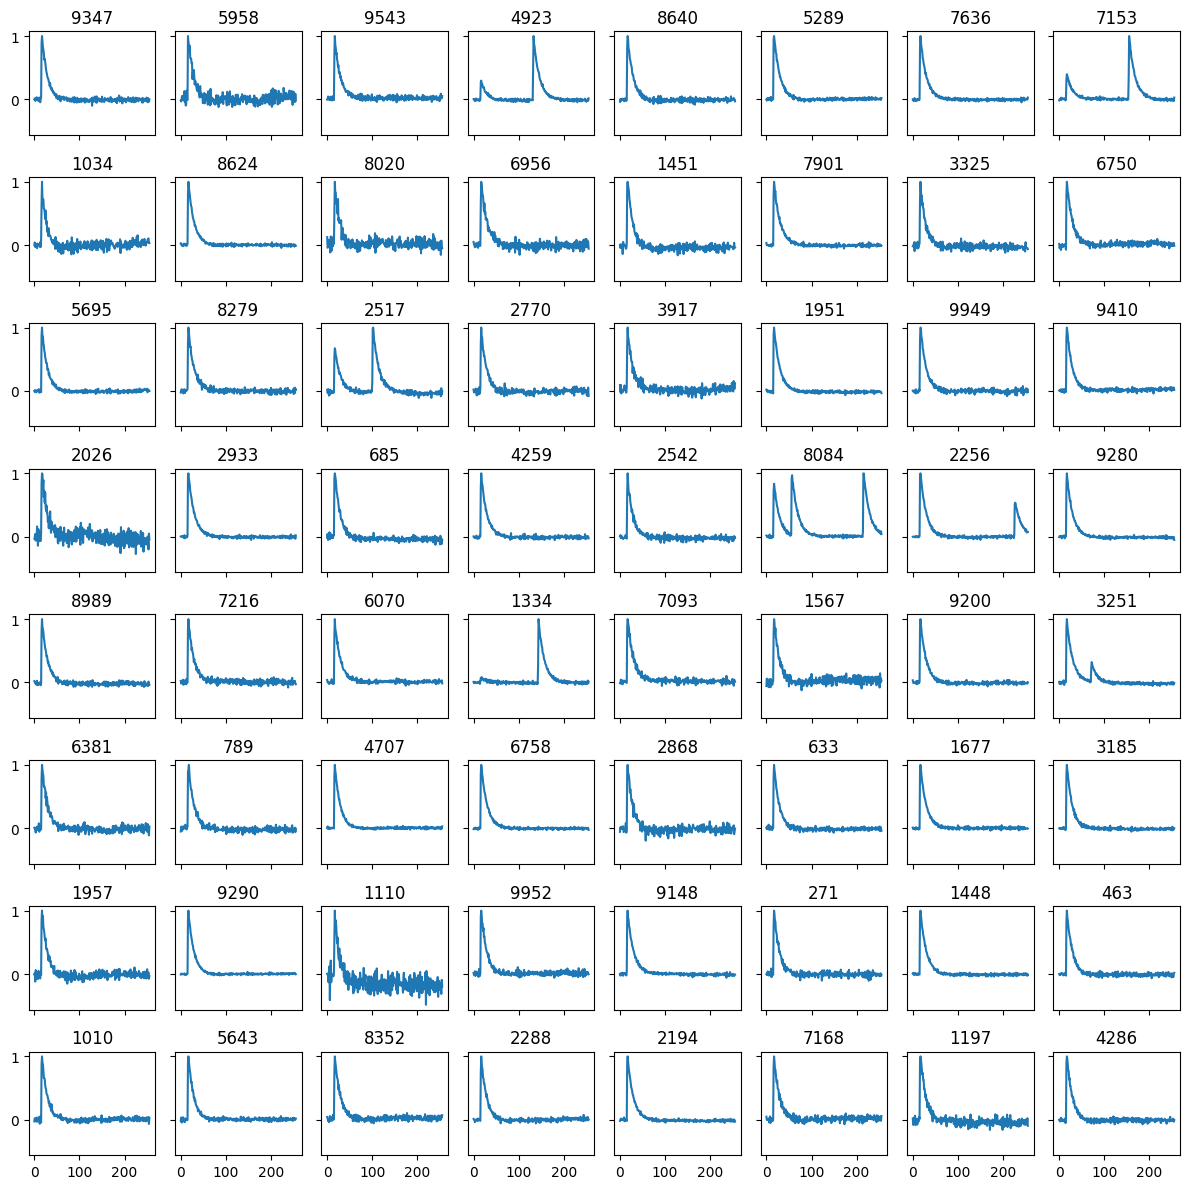

In [28]:
nRows = 8
nCols = 8
indices = np.random.choice(len(normPulses), nCols*nRows, replace=False)

fig, ax = plt.subplots(nRows, nCols, sharex=True, sharey=True, figsize=(12, 12))

for a, idx in zip(ax.flat, indices):
    a.set_title(idx)
    a.plot(normPulses[idx])

plt.tight_layout()
plt.show()

Each pulse was normalized and downsampled before being fed into the clustering model. Downsampling was performed using a discrete wavelet transform (DWT). DWT decomposes a waveform into "mutually orthogonal down-sampled sets of time-series coefficients by convolving the input signal with a given type of wavelet" and can be performed multiple times on the same input signal [1]. The DWT outputs approximation coefficents (AC) and detail coefficents (DC), which describe the low and high frequency components of the input signal. The DWT de-noises and reduces the dimension of an input waveform. 

DWT "decomposes the waveform into mutually orthogonal down-sampled sets of time-series coefficients by convolving the input signal with a given type of wavelet" [1]. It can be done multiple, $l$, times on the same signal, with a multilevel decomposition with a factor of $2^l$.

The DWT outputs approimate coefficents (aC, low freq $\rightarrow$ low pass filter) and detail coefficents (dC, high freq$\rightarrow$ high pass filter) components of the input signal. They take AC as a lower-dimensional representation of input waveform. 

[1] used the Haar wavelet for DWT to preserve the rising edge shape and the decay time.

In [14]:
# normalize w p0
offsets = np.median(pulses['waveform'][:,:floor(prepulse_len/2)], axis=1) + pulses['p0']
baselinePulses = np.subtract(pulses['waveform'], offsets[:, None])
normPulses = np.divide(baselinePulses, np.max(baselinePulses, axis=1)[:,None])

In [16]:
# DWT to each pulse
w='haar'
level=3
coeffs = pywt.wavedec(normPulses, w, level=level)
cA3, cD3, cD2, cD1 = coeffs # cA3 is a smoothed with 1/8 length of normal
time8 = range(int(floor(prepulse_len + pulse_len)/8))

In [17]:
print(w)
print(len(coeffs))

haar
4


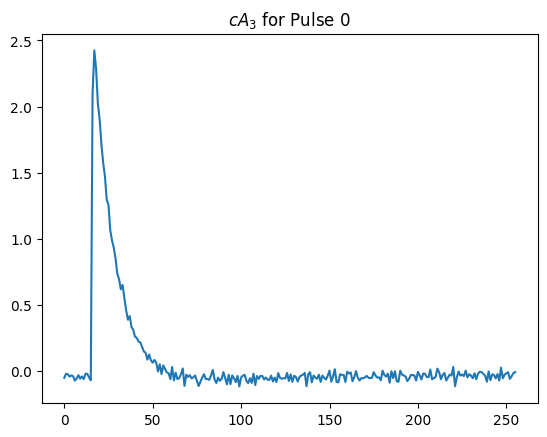

In [22]:
plt.plot(cA3[0])
plt.title(r'$cA_3$ for Pulse 0')
plt.show()
plt.close()

Since our input waveforms contain 2048 samples, we use a value of $l = 3$ to reduce the dimension to 256 samples. Using the PyWavelets library this results in four transforms: $cD_3, cA_3, cA_2, cA_1$. We will use $cD_3$ as the downsampled signals. 

I finally normalize the AC by the absolute value of their maximum or minimum amplitude, whichever one is greater, such that the values of the AC lie in the [−1,1] range. Note that the time sacle has been downsampled by a factor of 8: $2048 \rightarrow 256$ samples. This makes the each sample represents 6.4 $\mu$s. 

Min/max normalization, dwt (use L1/manhatten if possible)

# Unsupervised Clustering

## AP Overview

***How AP works, why are we using this, `apParamSweep.py`***

## AP Param Search

Below are the results of the AP parameter serach.

In [50]:
ap_param_grid = pd.read_pickle(f'../data/20260804_ap_grid_day16_chan03_10000_20260803.pkl')
ap_best_load = joblib.load(f'../data/20260804_best_ap_day16_chan03_10000_20260803.pkl')

In [49]:
ap_param_grid.head()

,preference,damping,n_clusters,converged
0,-27.941062,0.75,174,True
1,-26.312706,0.75,180,True
2,-24.684350,0.75,194,True
3,-23.055993,0.75,207,True
4,-21.427637,0.75,234,True


Now lets make a plot of the parameter search:

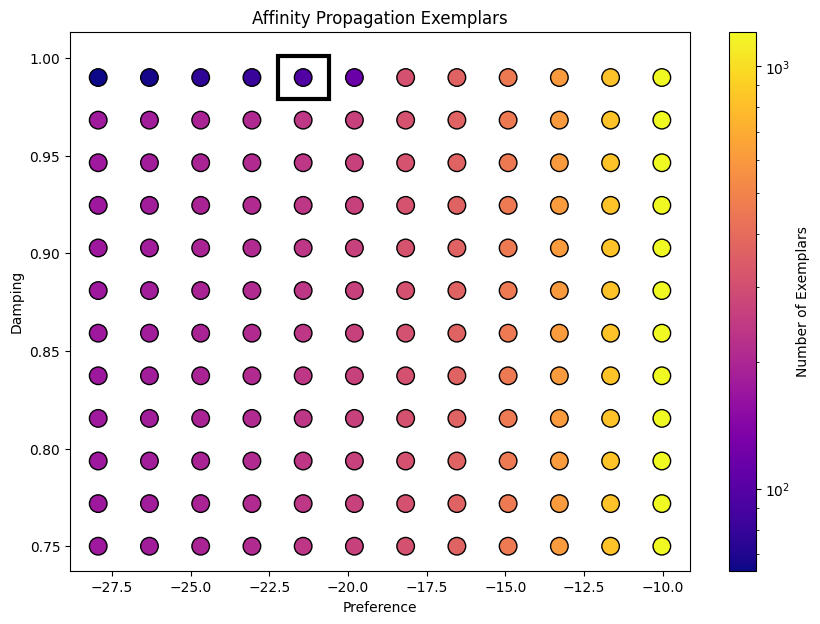

In [59]:
plt.figure(figsize=(10, 7))

sc = plt.scatter(
    ap_param_grid['preference'],
    ap_param_grid['damping'],
    c=ap_param_grid['n_clusters'],
    cmap='plasma',
    norm=mt.colors.LogNorm(),
    s=160,
    edgecolors='black'
)

plt.colorbar(sc, label='Number of Exemplars')

ax = plt.gca()

# Estimate box size from grid spacing
pref_step = np.diff(np.sort(ap_param_grid['preference'].unique())).mean()
damp_step = np.diff(np.sort(ap_param_grid['damping'].unique())).mean()

rect = Rectangle(
    (
        ap_best_load['best_params']['preference'] - pref_step / 2,
        ap_best_load['best_params']['damping'] - damp_step / 2
    ),
    pref_step,
    damp_step,
    fill=False,
    linewidth=3
)

ax.add_patch(rect)

plt.xlabel('Preference')
plt.ylabel('Damping')
plt.title('Affinity Propagation Exemplars')

#plt.savefig('../outputs/figs/ap_param_sweep.png')
#plt.savefig('../outputs/figs/ap_param_sweep.svg', format='svg', dpi=1200)

plt.show()
plt.close()

In [61]:
print(ap_best_load)

{'model': {'preference': -21.427636756987663, 'damping': 0.99, 'n_clusters': 95, 'converged': True}, 'best_params': {'preference': -21.427636756987663, 'damping': 0.99}, 'target_clusters': 100, 'wavelet': 'haar', 'dwt_level': 3, 'similarity_metric': 'l1', 'normalization': 'max_abs', 'median_similarity': -10.029142033107043}


Here we see that the best model the parameter seach found. 

## Best AP Model Results

Okay I need to load the examplars from the best model. 

In [41]:
ap_load

{'model': {'preference': -21.427636756987663,
  'damping': 0.99,
  'n_clusters': 95,
  'converged': True},
 'best_params': {'preference': -21.427636756987663, 'damping': 0.99},
 'target_clusters': 100,
 'wavelet': 'haar',
 'dwt_level': 3,
 'similarity_metric': 'l1',
 'normalization': 'max_abs',
 'median_similarity': -10.029142033107043}

# Manual Cluster Sorting

# Overview

Here is an overview of the pipeline for this. The pipeline is broken into individual scripts (described below) that do each part of the following:

 * Get pulses from raw data: `pulseGrabber.py`
 * Select $N$ pulses to train an ML model: `getNPulses.py`
 * Run a parameter seach to find the optimal AP model: `apParamSweep.py`
 * Manually sort clusters from the best AP model: ***TO DO***
 * Run a parameter seach to find the optimal SVM model: `svmParamSweep.py` (see [1] for more info when writing this)


* Get pulses using `pulseGrabber.py`. Does the following:
    * saves all pulses from each 10-min time chunk to a .npy file. If a file already exists then skip that chan/chunk pair. If you want to redo a selection, either put a different `save_directory` or delete the current directory/file(s). Saves the following informations:
        * `waveform`
            * waveform of pulses. Length of 2048 samples (128 prepulse, 1920 pulse)
            * np.float32 (pulse_len,)
        * `ig_laser`
            * Whether the laser was 
            * np.bool
        * `multiplicity`
            * Number of channels with simultaneous pulses
            * np.int32
        * `energy`
            * Energy of pulse after calibration corrections (see https://doi.org/10.1103/PhysRevD.111.052010 [2] for more info)
            * np.float32
        * `p0`
            * Calibration parameter (see [2])
            * np.float32
    * Each 10-min chunk of pulses is \approx$ 1&ndash;1.3 GB of pulses. All pulses arrays are stored in a dir in `/data_fast/chinkle/26_ml/allPulses/out_pulses_{day}_{all or chan list}`. Each channel and time chunk are saved independetly. File names are formated as following:
        * `{save_dir}/{time metadata from tdms}_{sig A/B}_{time chunk}_{chan}.npy`
            * ex all: `/data_fast/chinkle/26_ml/allPulses/out_pulses_33_all/20221129-030020.093762_A_000_02.npy`
            * ex one chan: `/data_fast/chinkle/26_ml/allPulses/out_pulses_16_ch3/20221106-231354.459620_A_004_03.npy`
    * Inputs (on command line):
        * `tdms_directory`
            * Directory where raw TDMS files are stored
            * Not required, default hard coded as day 16
        * `h5_directory`
            * Directory where associated h5 files are stored
            * Not required, default hard coded as day 16
        * `save_directory`
            * Directory where template pulses will be stored
            * Not required, default logic above
        * `threads`
            * Max threads to launch. Max 48 cores on CRONOS
            * Not required, default to 20 threads
        * `chans`
            * Channels to save pulses from. Seperate using spaces. Ex. --chans 0 1 2
            * Not required, default all chans

* Select $N$ pulses from a directory (typically one day) using `getNPulses.py`
    * Parse arguments as `args`
    * Set seed if provided
    * file_map = makeFileMap()
        * create a map of of (chunk, chan) $\rightarrow$ filename
        * inputs
            * `pulse_directory`
            * `channels`
    * dtype = getPulseDtype()
        * Set the `dtype` to save pulses
    * save_loc = makeSaveName(args)
        * get today's date, day, and channels. Create save_loc based on `save_directory`.
        * If the file already exists add `_#` at the end. 
        * inputs
            * `args`
    * pulses = samplePulse()
        * get $N$ samples from the file map
        * Look at each (chunk, channel) and sample randomly from that file as many times as that (chunk, channel) is in the file map
        * Return the pulses
        * inputs
            * `file_map`
            * `args.n_samples`
            * `dtype`
    * save `pulses` to `save_loc`
    * 
    * Inputs (on command line):
        * `save_directory`
            * Directory to save N pulses to. The filename will automatically generated be based on filename, chans (if included), and date
            * Not required, default `/data_fast/chinkle/26_ml/selectedPulses/`
        * `pulse_directory`
            * Directory to sample pulses from. Input data must follow from pulses saved using `pulseGrabber.py `
            * Required, no default
        * `n_samples`
            * Numer of samples to save
            * Not required, default 5000 
        * `chans`
            * Channel(s) to sample from. List with spaces. Ex: 0 2 10
            * Not required, default all chans
        * `seed`
            * Random seed
            * Not required, no default

* Load pulses from a npy array, pre-process, and run a parameter search for AP clustering using `apParamSweep.py`
    * Parse arguments as `args`
    * Load pulses from `args.pulse_directory`
    * Preprocess the pulses. We want to downsample the pusles before feeding into AP due to time and memory constraints.
        * Apply DWT to downsample $2048\rightarrow256$ samples
        * Normalize baseline to 0 and pulse height to 1
    * Calculate similarity matrix using an $\ell _1$ norm. See [1] for more info.
    * Set preferance and damping ranges
    * Run AP param search
        * Using multithreading run AP using various preferance and dampings. Run AP and return whether it converged, number of clusters, preferance, and damping. 
        * Inputs
            * param_grid
            * S
            * args
    * Convert to a df and save at `save_directory` based on the pulse_file given:
        * Save the same file name with `{todays date}\_ap\_grid_` before it
        * Ex:
            * input `/{pulse_dir}/day16_chan03_5000_20260729_filtered_norm.npy`
            * output `/{save_dir}/20260803_ap_grid_day16_chan03_5000_20260729_filtered_norm.pkl`
    * Inputs (on command line):
        * `pulse_file`
            * File where the selected pulses are stored. Input data must follow from pulses saved using `getNPulses.py `
            * Required, no default
        * `save_directory`
            * Directory where AP parameter search results will be stored
            * Not required, default dir: `/data_fast/chinkle/26_ml/apResults/`, filename generated as described above
        * `threads`
            * Max threads to launch. Max 48 on CRONOS
            * Not required, default 20 threads
        * `pref_range`
            * Minimum and maximum preference values. Must provide exactly two values.
            * Not required, default: [-10, min(S)] 
        * `damp_range`
            * Minimum and maximum damping values. Must provide exactly two values.
            * Not required, default: [0.75, 0.99]'
        * `seed`
            * Random seed
            * Not required, no default
        * `max_iter`
            * Max iterations to run AP
            * Not required, default 500
        * `converge_iter`
            *  Number of iterations with no change in the number of estimated clusters that stops the convergence
            *  Not required, default 15
        * `target_clusters`
            *  Target number of clusters for AP
            *  Not required, default 100


 ## Notes
Calibrated energy is not needed per inwook. Going to take it out (maybe, maybe jsut keep it) when I rerun everything. 

Use `drift_corrected_energy_substr_corr_rescaled` instead. Changed `calibrated_energy` to `energy`, `calibration_parameters` to `p0` (likely will keep). 

changed `pulseGrabberChan.py` to `pulseGrabber.py`

redoing `getNPulses.py` to be modular and a good python program

not actually temporally uniform. it is uniform across chunks and then uniform across pulses in a chunk. slight difference here.

maybe do 10k instead of 5k

okay, I have made the pipeline through AP. I am going to delete the current stuff for day 16 (just leave day 33 andn write about day 16 chan 3) and rerun using the full pipeline. 


## Overall flowchart
Assuming no files have been made for the day yet do the following:

 * Run `pulseGrabber.py`
     * Need to know `h5` and `tdms` files for these days
     * Specify channel 3
     * Will create a directory with all the pulses
 * Run `getNPulses.py` to select 10 000 pulses from the create direcrtory above
 * Run `apParamSweep.py`

I want to know the time and memory usage for each process. I also want to know the size of each file/directory created. 

### Notes

I ran `/usr/bin/time -v python3 pulseGrabber.py --chans 3` for day 16. I used the defaults for everything else (20 threads, auto `save_dir`, hard coded day 16 `tdms` and `h5`. 

Fist run didn't work, there was no `drift_corrected_energy_substr_corr_rescaled`. I will find one that has this. 

In [29]:
import pandas as pd

In [30]:
#h5Day16 = '/beest_data/finalProcessingBlinded-20250519/magcycle-33-221128/processed/chewed_metadata_20221129-224243.971075_Sig_A.h5'
h5Day16 = r'/beest_data/finalProcessingBlinded-20250519/magcycle-16-221106/processed/chewed_metadata_20221106-223352.840919_Sig_A.h5'

In [31]:
df16_3_processed = pd.read_hdf(h5Day16, key=f'data_channel3')

In [32]:
print(df16_3_processed.columns.tolist())


['filename', 'trigger_position_corrected', 'trigger_position', 'trigger_value', 'trigger_level_in_ADC', 'head0', 'head1', 'head2', 'tail1', 'tail2', 'head0_std', 'head1_std', 'head2_std', 'tail1_std', 'tail2_std', 'max0', 'max1', 'max2', 'fp1', 'fp3', 'fp5', 'fp8', 'fp9', 'mt0', 'mt1', 'mt2', 'mt50p0', 'mt50p1', 'mt50p2', 'mt20p0', 'mt20p1', 'mt20p2', 'int0', 'int1', 'int2', 'flattop1_mean', 'flattop2_mean', 'flattop1_std', 'flattop2_std', 'trig_pos_corr_fit', 'head2_fit', 'flat2_fit', 'trig_pos_corr_err', 'head2_err', 'max2_err', 'lsq_err', 'time', 'ig_laser', 'ig_laser_pileup', 'multiplicity', 'coincident_channels', 'coincident_positions', 'sumV', 'multiplicity_delayed', 'coincident_channels_delayed', 'coincident_positions_delayed', 'sumV_delayed', 'calibrated_laser_substr_corr', 'calibrated_physics_substr_corr', 'calibrated_energy_substr_corr', 'drift_corrected_energy_substr_corr', 'drift_corrected_energy_substr_corr_rescaled']


This looks good. I will use this. I got rid of `p0` because it was causing issues and its not needed. 

`pulseGrabber.py` worked. Some of the times didn't work (this is to be expected, every other one had some issues). I just did channel 3 day 16. 

Channels that didnt work: 3, 14, 23,26, 53, 64, 71, 95, 102, 121

Rerunning once to see if it will do any different ones this time. No difference on the new one.



In [33]:
memKb = 1077316 #kb
userTime = 54775.44 #s
sysTime = 6859.52 #s
cpuPer = 1543 #%

In [34]:
print(f'Memory used: {memKb * 1e-6: .2f} GB')
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/3600:.2f} hr')
print(f'cpu percentage per core: {cpuPer/20}% (20 core total)')

Memory used:  1.08 GB
user time: 912.92 min = 15.22 hour
sys time: 114.33 min = 1.91 hour
CPU time: 61634.96 sec = 17.12 hr
cpu percentage per core: 77.15% (20 core total)


The script completed in 1 h 6 min 33 s of wall-clock time, consuming 17.1 CPU-hours (61,635 CPU seconds) with a peak memory usage of 1.03 GiB RAM.

Saved at `/data_fast/chinkle/26_ml/allPulses/out_pulses_16_chans_3/`

Now I am running `getNPulses.py` with 10 000 pulses. 

`/usr/bin/time -v python3 getNPulses.py --pulse_directory /data_fast/chinkle/26_ml/allPulses/out_pulses_16_chans_3/ --seed 23 --chans 3 --n_samples 10000`


In [35]:
memKb = 1489392 #kb
userTime = 2.10 #s
sysTime = 120.09 #s
cpuPer = 97 #%

In [36]:
print(f'Memory used: {memKb * 1e-6: .2f} GB')
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/60:.2f} min = {(userTime+sysTime)/3600:.2f} hr')
print(f'cpu percentage per core: {cpuPer}% ')

Memory used:  1.49 GB
user time: 0.04 min = 0.00 hour
sys time: 2.00 min = 0.03 hour
CPU time: 122.19 sec = 2.04 min = 0.03 hr
cpu percentage per core: 97% 


The script completed in 2 min 5.34 s of wall-clock time, consuming 2.04 CPU-minutes (122.19 CPU seconds) with a peak memory usage of 1.49 GiB RAM.

Saved at `/data_fast/chinkle/26_ml/selectedPulses/day16_chan03_10000_20260803.npy`

Now I ran `apParamSweep.py`. The ap param sweep is saved at `/data_fast/chinkle/26_ml/apResults/20260803_ap_grid_day16_chan03_10000_20260803.pkl`

In [37]:
memKb = 4733508 #kb
userTime = 57268.60 #s
sysTime = 3139.71 #s
cpuPer = 1898 #%

In [38]:
print(f'Memory used: {memKb * 1e-6: .2f} GB')
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/60:.2f} min = {(userTime+sysTime)/3600:.2f} hr')
print(f'cpu percentage per core: {cpuPer/20}% (20 threads used) ')

Memory used:  4.73 GB
user time: 954.48 min = 15.91 hour
sys time: 52.33 min = 0.87 hour
CPU time: 60408.31 sec = 1006.81 min = 16.78 hr
cpu percentage per core: 94.9% (20 threads used) 


The script completed in 53 min 01.51 s of wall-clock time, consuming 16.8 CPU-hours (60,408.31 CPU seconds) with a peak memory usage of 4.73 GiB RAM.

### AP analysis

In [39]:
results_df = pd.read_pickle('/data_fast/chinkle/26_ml/apResults/20260803_ap_grid_day16_chan03_10000_20260803.pkl')

In [40]:
results_df.head()

,preference,damping,n_clusters,converged
0,-50.00000,0.75,90,True
1,-69.20551,0.75,62,True
2,-88.41102,0.75,47,True
3,-107.61653,0.75,44,True
4,-126.82204,0.75,35,True


preference       -50.0
damping       0.924545
n_clusters          92
converged         True
Name: 96, dtype: object


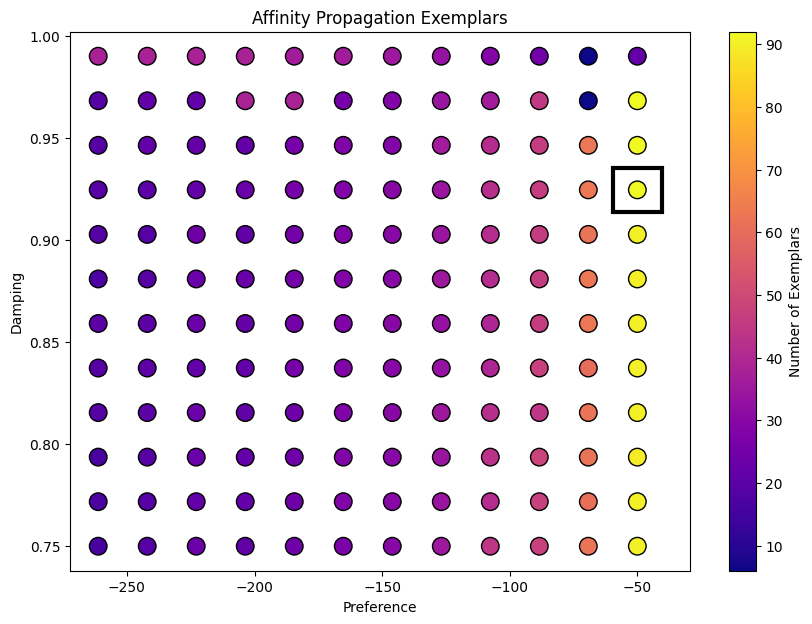

In [41]:
import matplotlib as mt 
from matplotlib.patches import Rectangle

target_clusters = 100
valid_df = results_df.dropna(subset=["n_clusters"]).copy()
best_idx = (
    valid_df["n_clusters"] - target_clusters
).abs().idxmin()

best_point = valid_df.loc[best_idx]

best_pref = best_point["preference"]
best_damp = best_point["damping"]
best_clusters = best_point["n_clusters"]

print(best_point)


plt.figure(figsize=(10, 7))

sc = plt.scatter(
    results_df["preference"],
    results_df["damping"],
    c=results_df["n_clusters"],
    cmap='plasma',
    #norm=mt.colors.LogNorm(),
    s=160,
    edgecolors='black'
)

plt.colorbar(sc, label='Number of Exemplars')

ax = plt.gca()

# Estimate box size from grid spacing
pref_step = np.diff(np.sort(results_df["preference"].unique())).mean()
damp_step = np.diff(np.sort(results_df["damping"].unique())).mean()

rect = Rectangle(
    (
        best_pref - pref_step / 2,
        best_damp - damp_step / 2
    ),
    pref_step,
    damp_step,
    fill=False,
    linewidth=3
)

ax.add_patch(rect)

plt.xlabel('Preference')
plt.ylabel('Damping')
plt.title('Affinity Propagation Exemplars')

#plt.savefig('ap_param_sweep.png')

plt.show()
plt.close()

In [42]:
results_df['preference'].min()

-261.26061025145464

In [43]:
results_df['preference'].max()

-50.0

#### AP analysis 2

I will rerun with a different preference range : (max(S), -20) and damping range: (0.65, 0.99). 

I ran `apParamSweep.py` again. The ap param sweep is saved at `/data_fast/chinkle/26_ml/apResults/20260804_ap_grid_day16_chan03_10000_20260803.pkl`

In [44]:
memKb = 4800408 #kb
userTime = 53959.87 #s
sysTime = 4716.27 #s
cpuPer = 1890 #%

In [45]:
print(f'Memory used: {memKb * 1e-6: .2f} GB')
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/60:.2f} min = {(userTime+sysTime)/3600:.2f} hr')
print(f'cpu percentage per core: {cpuPer/20}% (20 threads used) ')

Memory used:  4.80 GB
user time: 899.33 min = 14.99 hour
sys time: 78.60 min = 1.31 hour
CPU time: 58676.14 sec = 977.94 min = 16.30 hr
cpu percentage per core: 94.5% (20 threads used) 


The script completed in 51 min 44.44 s of wall-clock time, consuming 16.3 CPU-hours (58,676.14 CPU seconds) with a peak memory usage of 4.80 GiB RAM.

In [46]:
results_df_2 = pd.read_pickle('/data_fast/chinkle/26_ml/apResults/20260804_ap_grid_day16_chan03_10000_20260803.pkl')

In [47]:
results_df_2.head()

,preference,damping,n_clusters,converged
0,-20.000000,0.65,262,True
1,-41.932783,0.65,120,True
2,-63.865566,0.65,66,True
3,-85.798348,0.65,45,True
4,-107.731131,0.65,41,True


preference   -20.0
damping       0.99
n_clusters     115
converged     True
Name: 132, dtype: object


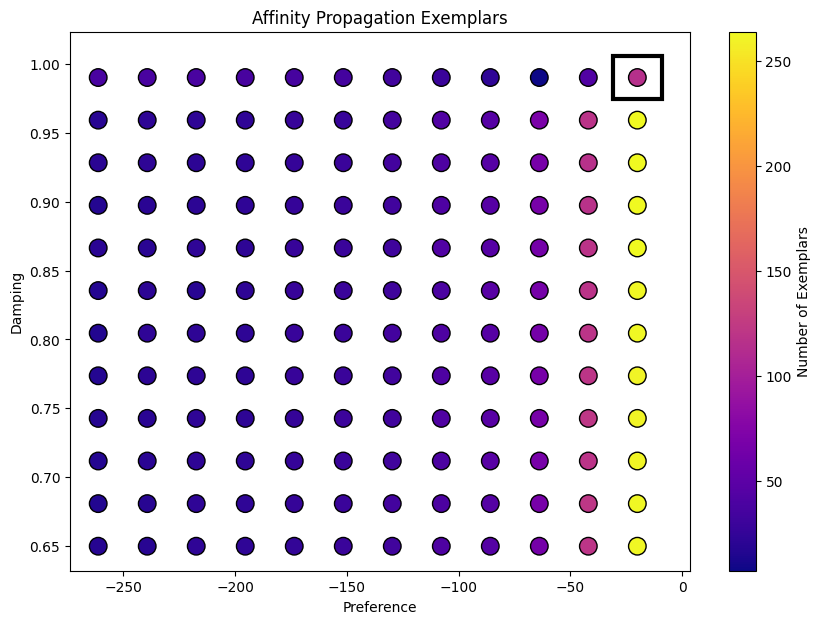

In [48]:
target_clusters = 100
valid_df = results_df_2.dropna(subset=["n_clusters"]).copy()
best_idx = (
    valid_df["n_clusters"] - target_clusters
).abs().idxmin()

best_point = valid_df.loc[best_idx]

best_pref = best_point["preference"]
best_damp = best_point["damping"]
best_clusters = best_point["n_clusters"]

print(best_point)


plt.figure(figsize=(10, 7))

sc = plt.scatter(
    results_df_2["preference"],
    results_df_2["damping"],
    c=results_df_2["n_clusters"],
    cmap='plasma',
    #norm=mt.colors.LogNorm(),
    s=160,
    edgecolors='black'
)

plt.colorbar(sc, label='Number of Exemplars')

ax = plt.gca()

# Estimate box size from grid spacing
pref_step = np.diff(np.sort(results_df_2["preference"].unique())).mean()
damp_step = np.diff(np.sort(results_df_2["damping"].unique())).mean()

rect = Rectangle(
    (
        best_pref - pref_step / 2,
        best_damp - damp_step / 2
    ),
    pref_step,
    damp_step,
    fill=False,
    linewidth=3
)

ax.add_patch(rect)

plt.xlabel('Preference')
plt.ylabel('Damping')
plt.title('Affinity Propagation Exemplars')

#plt.savefig('ap_param_sweep.png')

plt.show()
plt.close()